# Exploratory Data Analysis for Resume Data
The dataset can be found on kaggle here: https://www.kaggle.com/datasets/dare2dream/resume-extraction?resource=download.

In [30]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('data/raw_data.csv')
df.columns = df.columns.str.strip()
df.head()

/var/folders/gk/2sjtbc5x2rs_8qpg45qxk2_m0000gq/T/ipykernel_84400/625133040.py:1: DtypeWarning: Columns (0: Gender, 1: Education, 2: Specialization, 3: interests, 4: skills , 5: Certifications, 6: Job_status, 7: Job_title, 8: Highest Qualification) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/raw_data.csv')


,Gender,Education,Specialization,interests,skills,Yearly salary in pounds,Certifications,Job_status,Job_title,Highest Qualification
0,Female,B.E,Mechanical,Technology,"Critical Thinking, Analytic Thinking, SQL, Pro...",44,Microsoft certification,Yes,Computer Software Engineer,NaN
1,Male,BA,English,Understand human behaviour,People management;Communication skills,46,Resilience psychology,No,NaN,NaN
2,Female,MBA,Marketing,Sales/Marketing;Trading;Understand human behav...,Accounting Skills;Critical Thinking,75,No,Yes,Relationships manager,NaN
3,Female,B.Tech,Computer,Technology,"C,C++,Java",62,W3schools,Yes,Plant Instrumentation Engineer,NaN
4,Female,B.Tech,Mechanical,Technology,"C,C++,HTML,Java",56,"C,C++,HTML,Java",Yes,Network analyst,NaN


In [32]:
print(df.shape)
df.info()

(1048575, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column                   Non-Null Count    Dtype
---  ------                   --------------    -----
 0   Gender                   804349 non-null   str  
 1   Education                804349 non-null   str  
 2   Specialization           804349 non-null   str  
 3   interests                791467 non-null   str  
 4   skills                   798656 non-null   str  
 5   Yearly salary in pounds  1048575 non-null  int64
 6   Certifications           789887 non-null   str  
 7   Job_status               789961 non-null   str  
 8   Job_title                594247 non-null   str  
 9   Highest Qualification    289258 non-null   str  
dtypes: int64(1), str(9)
memory usage: 80.0 MB


In [33]:
# Check for missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})

,Missing Count,Missing %
Highest Qualification,759317,72.414181
Job_title,454328,43.328136
Certifications,258688,24.670434
Job_status,258614,24.663376
interests,257108,24.519753
skills,249919,23.834156
Gender,244226,23.291229
Education,244226,23.291229
Specialization,244226,23.291229
Yearly salary in pounds,0,0.000000


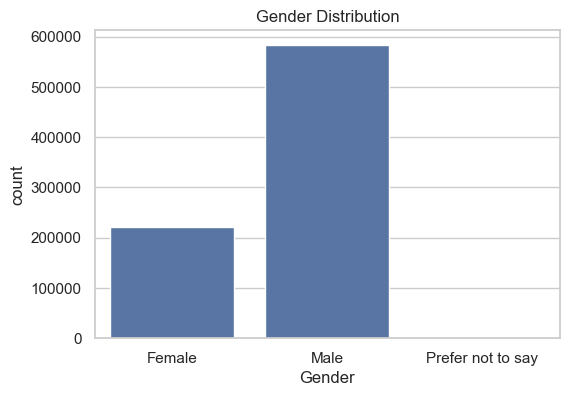

Gender
Male                 583717
Female               220398
Prefer not to say       234
Name: count, dtype: int64

In [ ]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

df['Gender'].value_counts()

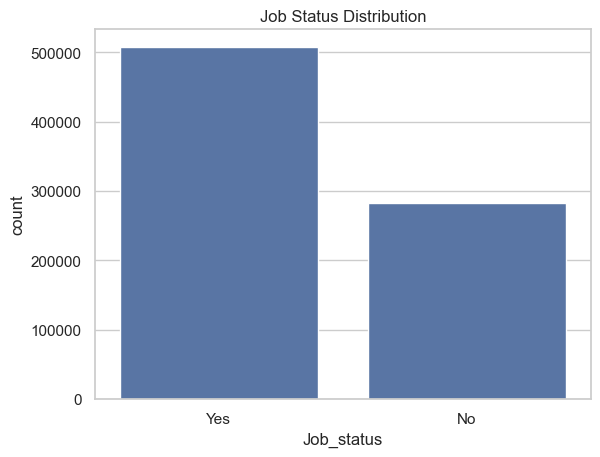

In [ ]:
# Job Status distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Job_status', data=df)
plt.title('Job Status Distribution')
plt.show()

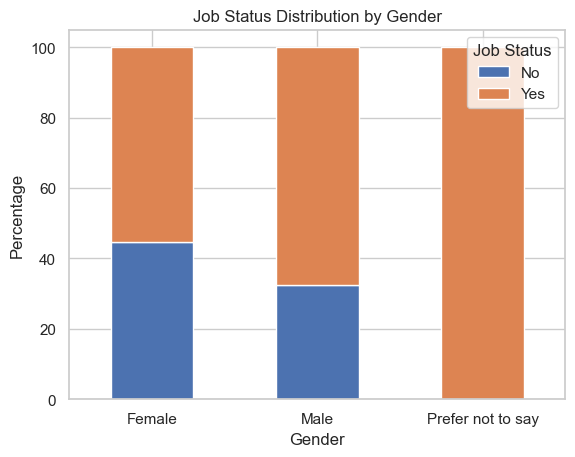

In [48]:
# Job Status Distribution by Gender
gender_job_percent = pd.crosstab(df['Gender'], df['Job_status'],normalize='index') * 100

gender_job_percent.plot(kind='bar', stacked=True,)
plt.title('Job Status Distribution by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Job Status')
plt.show()

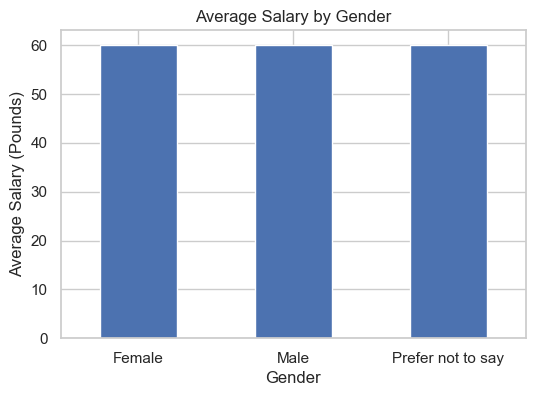

Gender
Female               59.990685
Male                 60.004086
Prefer not to say    60.059829
Name: Yearly salary in pounds, dtype: float64


In [49]:
# Average Salary by Gender
avg_salary = df.groupby("Gender")["Yearly salary in pounds"].mean()

avg_salary.plot(kind="bar", figsize=(6,4))
plt.ylabel("Average Salary (Pounds)")
plt.title("Average Salary by Gender")
plt.xticks(rotation=0)
plt.show()

print(avg_salary)

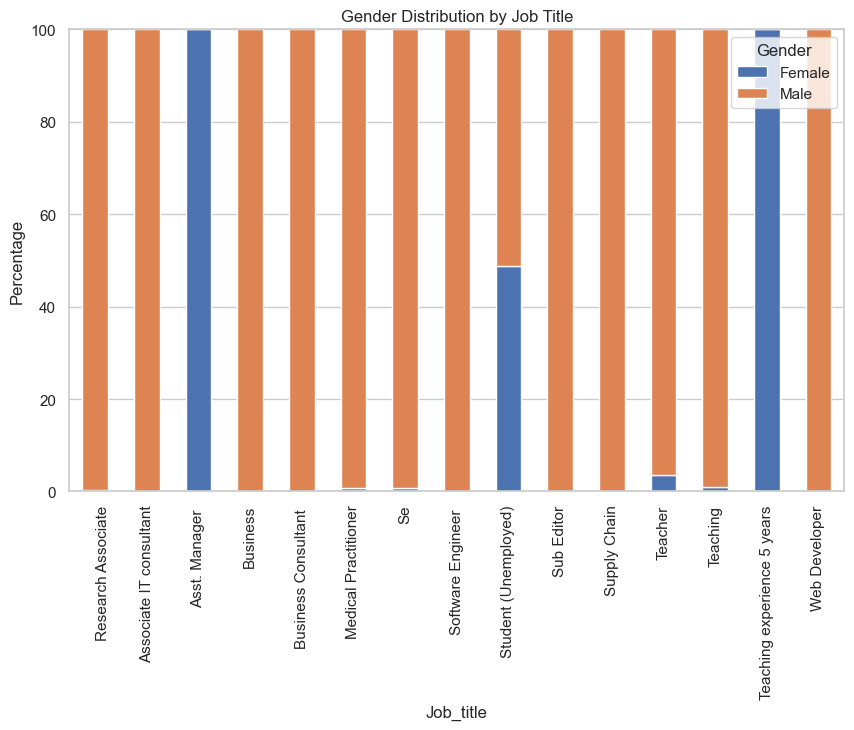

In [55]:
top_jobs = df["Job_title"].value_counts().head(15).index
gender_jobtitle_top = pd.crosstab(df[df["Job_title"].isin(top_jobs)]["Job_title"], df[df["Job_title"].isin(top_jobs)]["Gender"], normalize="index") * 100

gender_jobtitle_top.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Gender Distribution by Job Title")
plt.ylabel("Percentage")
plt.show()